# 실습 20: 회귀 - 데이터 처음 열어보기
- 상황: 기계 고장 기록이 새로 들어왔다. 이 표에 무엇이 들어 있나
- 목표: 행과 열의 크기, 열 이름, 숫자 열의 범위를 먼저 눈으로 확인한다

## Step 0. 데이터 불러오고 훑어보기

In [1]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv("../../data/16_machine-failure.csv", encoding="utf-8-sig")

# 2. 전체 행 수와 열 개수
print("전체 행 수:", df.shape[0])
print("열 개수:", df.shape[1])

# 3. 열 이름 전부 출력
print()
print("[열 이름]")
for 이름 in df.columns:
    print("-", 이름)

# 4. 숫자 열의 최소·최대·평균
print()
print("[숫자 열 요약]")
숫자열 = df.select_dtypes(include="number")
요약 = 숫자열.agg(["min", "max", "mean"]).T
print(요약.round(2))

전체 행 수: 10000
열 개수: 7

[열 이름]
- Type
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Machine failure

[숫자 열 요약]
                            min     max     mean
Air temperature [K]       295.3   304.5   300.00
Process temperature [K]   305.7   313.8   310.01
Rotational speed [rpm]   1168.0  2886.0  1538.78
Torque [Nm]                 3.8    76.6    39.99
Tool wear [min]             0.0   253.0   107.95


## Step 2. 맞힐 숫자 정하기

맞힐 것 : Process temperature [K] - 공정온도
왜 : 지금 조건에서 나와야 할 온도를 알면, 실제가 그보다 높을 때 이상 신호가 된다

### 문법 노트 - 회귀에서 새로 나오는 이름

| 쓴 것 | 하는 일 |
|---|---|
| mean_absolute_error | 평균 몇 만큼 빗나갔나 (MAE) |
| mean_squared_error | 제곱해서 평균 - 뿌리를 씌우면 RMSE |
| r2_score | 기준 모델 대비 얼마나 나은가 (R2) |
| LinearRegression | 숫자를 맞히는 모델 중 가장 단순한 것 |

## Step 3. 한 바퀴 돌리기

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. 입력과 결과 나누기
입력열 = ["Air temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
결과열 = "Process temperature [K]"

X = df[입력열]
y = df[결과열]

# 2. 학습용 80% / 시험용 20%
X_학습, X_시험, y_학습, y_시험 = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("학습용:", len(X_학습), "행 / 시험용:", len(X_시험), "행")

# 3. 기준 모델 - 늘 학습용의 평균값을 답한다
기준값 = y_학습.mean()
기준_예측 = [기준값] * len(y_시험)
print("기준 모델이 늘 답하는 값:", round(기준값, 2))

# 4. 선형회귀 모델 학습
모델 = LinearRegression()
모델.fit(X_학습, y_학습)
내_예측 = 모델.predict(X_시험)

# 5. 두 모델을 나란히 채점
점수 = pd.DataFrame(
    {
        "기준 모델": [
            mean_absolute_error(y_시험, 기준_예측),
            root_mean_squared_error(y_시험, 기준_예측),
            r2_score(y_시험, 기준_예측),
        ],
        "내 모델": [
            mean_absolute_error(y_시험, 내_예측),
            root_mean_squared_error(y_시험, 내_예측),
            r2_score(y_시험, 내_예측),
        ],
    },
    index=["MAE", "RMSE", "R2"],
)
print()
print(점수.round(4))

학습용: 8000 행 / 시험용: 2000 행
기준 모델이 늘 답하는 값: 310.01

       기준 모델    내 모델
MAE   1.2295  0.5950
RMSE  1.4727  0.7279
R2   -0.0000  0.7557


## Step 4. 무엇을 보고 맞혔나

                            계수      표준편차     영향력
Tool wear [min]        -0.0001   63.2251 -0.0042
Rotational speed [rpm] -0.0001  180.5941 -0.0179
Torque [Nm]            -0.0024    9.9792 -0.0244
Air temperature [K]     0.6517    2.0022  1.3048


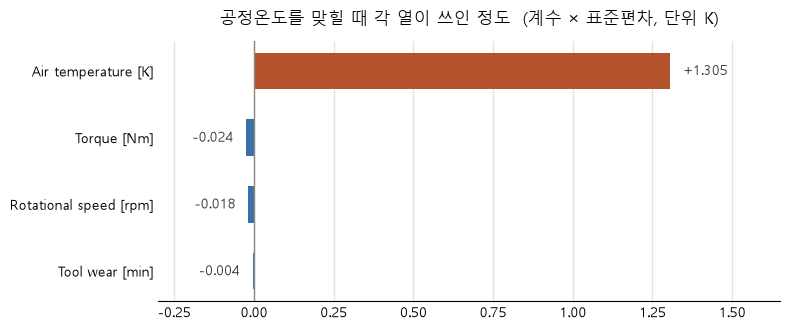

In [3]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 0. 한글 폰트 먼저 잡기 - 이걸 안 하면 글자가 네모로 깨진다
rcParams["font.family"] = "Malgun Gothic"
rcParams["axes.unicode_minus"] = False  # 마이너스 기호도 깨지지 않게

# 1. 계수를 그대로 비교하면 안 된다
#    회전속도는 1000 단위, 토크는 수십 단위라 '1 늘어난다'의 뜻이 서로 다르다
#    계수 x 학습용 표준편차 = '그 열이 평소 흔들리는 만큼 온도가 흔들리는 폭(K)'
영향력 = pd.DataFrame(
    {
        "계수": 모델.coef_,
        "표준편차": X_학습.std().values,
    },
    index=입력열,
)
영향력["영향력"] = 영향력["계수"] * 영향력["표준편차"]
영향력 = 영향력.sort_values("영향력", key=abs)

print(영향력.round(4))

# 2. 막대 그림 - 오른쪽은 온도를 올리는 방향, 왼쪽은 내리는 방향
색 = ["#B4522E" if 값 > 0 else "#3B6FA8" for 값 in 영향력["영향력"]]

fig, ax = plt.subplots(figsize=(8, 3.4))
실행 = ax.barh(영향력.index, 영향력["영향력"], color=색, height=0.55)
ax.axvline(0, color="#8a8a85", linewidth=1)

for 이름, 값 in zip(영향력.index, 영향력["영향력"]):
    ax.text(
        값 + (0.04 if 값 >= 0 else -0.04),
        이름,
        f"{값:+.3f}",
        va="center",
        ha="left" if 값 >= 0 else "right",
        fontsize=10,
        color="#3d3d38",
    )

ax.set_title(
    "공정온도를 맞힐 때 각 열이 쓰인 정도  (계수 × 표준편차, 단위 K)",
    fontsize=12,
    pad=12,
)
ax.set_xlim(-0.3, 1.65)
ax.xaxis.grid(True, color="#e5e5e0", linewidth=1)
ax.set_axisbelow(True)
for 테두리 in ["top", "right", "left"]:
    ax.spines[테두리].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

---
## 직접 해보기 (도전) - 대상을 바꾸면 자도 바뀐다

- 상황: 공정온도는 잘 맞혔는데, 다른 값도 같은 방식으로 되나
- 할 일: 맞히는 대상을 토크로 바꿔 한 번 더 돌리고 두 결과를 나란히 놓는다
- 결과물: 여섯 칸짜리 비교표 1개

In [4]:
# 1. 이번에는 토크를 맞힌다 - 공정온도가 입력 쪽으로 자리를 옮긴다
입력열_토크 = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Tool wear [min]",
]
결과열_토크 = "Torque [Nm]"

X2 = df[입력열_토크]
y2 = df[결과열_토크]

# 2. 학습용 80% / 시험용 20% - 앞과 같은 방식, 같은 random_state
X2_학습, X2_시험, y2_학습, y2_시험 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
print("학습용:", len(X2_학습), "행 / 시험용:", len(X2_시험), "행")

# 3. 기준 모델 - 늘 학습용의 평균값을 답한다
기준값2 = y2_학습.mean()
기준_예측2 = [기준값2] * len(y2_시험)
print("기준 모델이 늘 답하는 값:", round(기준값2, 2))

# 4. 선형회귀 모델 학습
모델2 = LinearRegression()
모델2.fit(X2_학습, y2_학습)
내_예측2 = 모델2.predict(X2_시험)

# 5. 토크 쪽 채점 - 기준 모델과 나란히
점수2 = pd.DataFrame(
    {
        "기준 모델": [
            mean_absolute_error(y2_시험, 기준_예측2),
            root_mean_squared_error(y2_시험, 기준_예측2),
            r2_score(y2_시험, 기준_예측2),
        ],
        "내 모델": [
            mean_absolute_error(y2_시험, 내_예측2),
            root_mean_squared_error(y2_시험, 내_예측2),
            r2_score(y2_시험, 내_예측2),
        ],
    },
    index=["MAE", "RMSE", "R2"],
)
print()
print("[토크 - 기준 모델 vs 내 모델]")
print(점수2.round(4))

# 6. 두 과제를 나란히 놓기
#    주의 - MAE와 RMSE는 단위가 다르다 (공정온도는 K, 토크는 Nm)
#    서로 크기를 비교할 수 있는 것은 단위가 없는 R2 뿐이다
비교 = pd.DataFrame(
    {
        "공정온도": 점수["내 모델"],
        "토크": 점수2["내 모델"],
    }
)
print()
print("[두 모델 나란히 보기]")
print(비교.round(4))

학습용: 8000 행 / 시험용: 2000 행
기준 모델이 늘 답하는 값: 40.01

[토크 - 기준 모델 vs 내 모델]
       기준 모델    내 모델
MAE   7.9050  3.6862
RMSE  9.9281  4.8979
R2   -0.0001  0.7566

[두 모델 나란히 보기]
        공정온도      토크
MAE   0.5950  3.6862
RMSE  0.7279  4.8979
R2    0.7557  0.7566
